/tmp/ipykernel_31968/1518358778.py:63: RuntimeWarning: invalid value encountered in divide
  corrected_image = (image - dark_field) / flood_field
/tmp/ipykernel_31968/1518358778.py:63: RuntimeWarning: divide by zero encountered in divide
  corrected_image = (image - dark_field) / flood_field


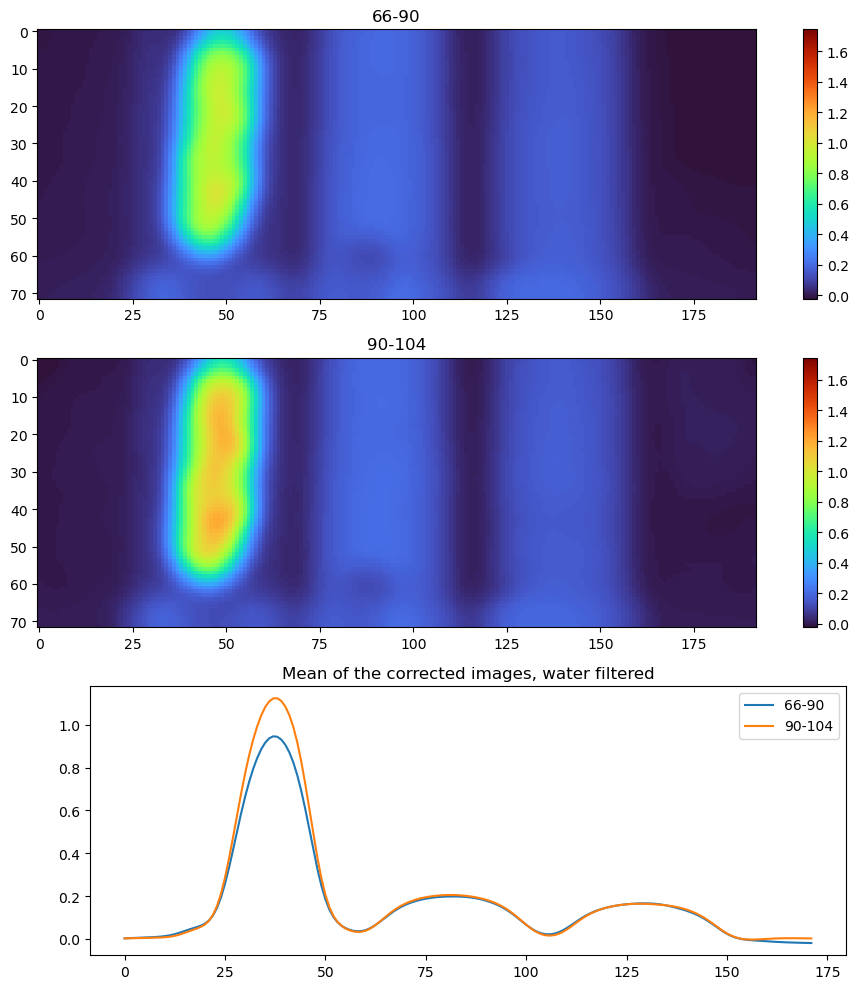

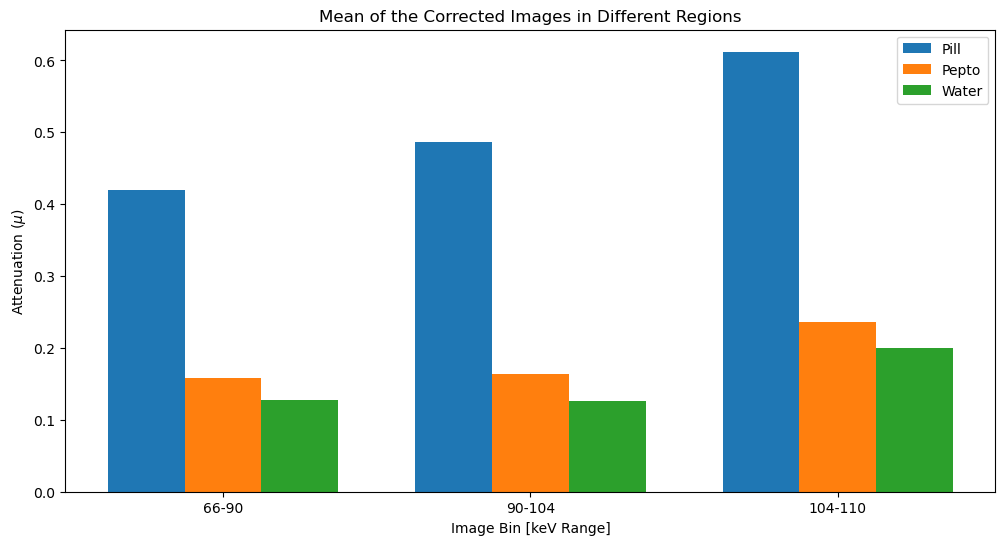

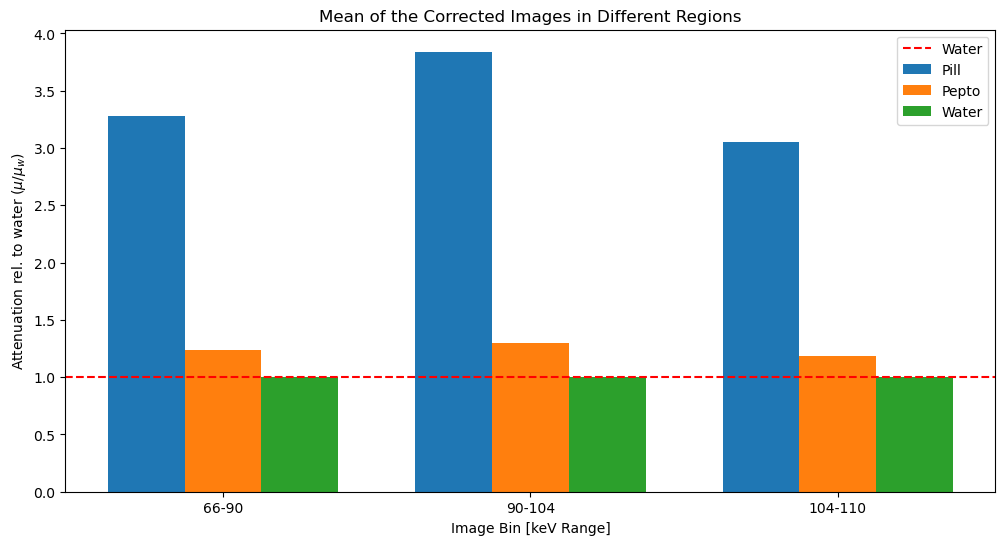

In [4]:
# %%
# Looking at the pepto images

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import mpl_interactions as pli

# Define the root directory to start the search
root_dir = './'

# Load .npy files
data_list, data_names = [], []
for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.npy'):
            file_path = os.path.join(subdir, file)
            data_list.append(np.load(file_path))
            data_names.append(file_path)

# Sort data names and data list
data_list = [x for _, x in sorted(zip(data_names, data_list))]
data_names = sorted(data_names)
data_list = np.array(data_list)

# %%
# Define image groups
two_views = data_list.squeeze()[:7]
darks = data_list.squeeze()[7:14]
inverted = data_list.squeeze()[14:21]
floods = data_list.squeeze()[21:28]
bismuth_filtered = data_list.squeeze()[28:35]
water_filtered = data_list.squeeze()[35:42]
Original_test = data_list.squeeze()[42:49]

# %%
# Function to detect and correct pixels
def detect_and_correct_pixels(image, lower_threshold, upper_threshold):
    corrected_image = image.copy()
    underresponding_mask = image < lower_threshold
    overresponding_mask = image > upper_threshold

    def mean_of_neighbors(img, x, y):
        neighbors = [img[i, j] for i in range(max(0, x-1), min(img.shape[0], x+2))
                     for j in range(max(0, y-1), min(img.shape[1], y+2)) if (i, j) != (x, y)]
        return np.mean(neighbors)

    for x, y in np.argwhere(underresponding_mask):
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    for x, y in np.argwhere(overresponding_mask):
        corrected_image[x, y] = mean_of_neighbors(image, x, y)

    return corrected_image

# Correct the images
corrected_images = []
for i in range(6):
    dark_field, flood_field, image = darks[i], floods[i], bismuth_filtered[i].copy()
    flood_field -= dark_field
    flood_field = flood_field / np.mean(flood_field[:15, 20:-20]) * np.mean(image[:15, 20:-20])
    corrected_image = (image - dark_field) / flood_field
    corrected_image = np.clip(corrected_image, 0.1, 2)
    corrected_image[np.isnan(corrected_image)] = 0.1

    mean, std = np.mean(corrected_image), np.std(corrected_image)
    lower_threshold, upper_threshold = mean - std, mean + std
    corrected_image = detect_and_correct_pixels(corrected_image, lower_threshold, upper_threshold)
    corrected_images.append(-np.log(corrected_image))

corrected_images = [gaussian_filter(image, 3) for image in corrected_images]

# %%
# Plot the median of the corrected images
bins = np.array([20, 30, 76, 100, 114, 120]) - 10
names = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]

plt.figure(figsize=(10, 10))
for i in range(2, 4):
    plt.subplot(3, 1, i-1)
    plt.title(names[i])
    plt.imshow(np.rot90(corrected_images[i]), cmap='turbo', vmin=np.percentile(corrected_images[5], 1), vmax=np.percentile(corrected_images[5], 99))
    plt.colorbar()

# Plot the median of the corrected images along a specific axis
plt.subplot(3, 1, 3)
for i in range(2, 4):
    plt.plot(np.mean(corrected_images[i][10:-10, 20:-20], axis=1), label=names[i])
plt.gca().set_aspect(20 * (corrected_images[2].shape[0] / corrected_images[2].shape[1]), adjustable='box')
plt.legend()
plt.title('Mean of the corrected images, water filtered')
plt.tight_layout()
plt.show()

# %%
# Bar chart of the mean of the regions
regions = [[25, 50], [75, 90], [120, 140]]
region_names = ['Pill', 'Pepto', 'Water']


# %%
# Bar chart of mean values for specified regions
values = []
for i in range(3):
    region_values = [np.mean(corrected_images[j][regions[i][0]:regions[i][1], 10:-10]) for j in range(2, 5)]
    values.append(region_values)

values = np.array(values)
x = np.arange(2, 5)
width = 0.25

plt.figure(figsize=(12, 6))
for i in range(3):
    plt.bar(x + i * width, values[i], width, label=region_names[i])
plt.xlabel('Image Bin [keV Range]')
plt.ylabel('Attenuation ($\mu$)')
plt.title('Mean of the Corrected Images in Different Regions')
plt.xticks(x + width, [f'{name}' for name in names[2:5]])
plt.legend()
plt.show()

# %%
# Bar chart of relative attenuation to water
values = []
for i in range(3):
    region_values = [np.mean(corrected_images[j][regions[i][0]:regions[i][1], 10:-10]) / np.mean(corrected_images[j][regions[2][0]:regions[2][1], 10:-10]) for j in range(2, 5)]
    values.append(region_values)

values = np.array(values)
x = np.arange(2, 5)
width = 0.25

plt.figure(figsize=(12, 6))
for i in range(3):
    plt.bar(x + i * width, values[i], width, label=region_names[i])
plt.xlabel('Image Bin [keV Range]')
plt.ylabel('Attenuation rel. to water ($\mu/\mu_w$)')
plt.title('Mean of the Corrected Images in Different Regions')
plt.xticks(x + width, [f'{name}' for name in names[2:5]])
plt.axhline(1, color='red', linestyle='--', label='Water')
plt.legend()
plt.show()